# 1. UAV-Flow 数据集探索

本 Notebook 带你了解 UAV-Flow 数据集的结构和内容。UAV-Flow 是一个基于真实校园场景的无人机飞行数据集，包含 FPV（第一人称视角）图像、语言指令和 6-DoF 飞行动作。

**学习目标：**
- 理解数据集的目录结构和文件格式
- 可视化无人机 FPV 图像
- 理解飞行轨迹和动作空间
- 分析动作的统计分布

## 1.1 环境准备

In [1]:
import json
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

# 数据路径
DATA_DIR = Path("/root/autodl-fs/claude/data/uav_flow_subset")
print(f"数据目录: {DATA_DIR}")
print(f"轨迹数量: {len(list(DATA_DIR.iterdir()))}")

数据目录: /root/autodl-fs/claude/data/uav_flow_subset
轨迹数量: 500


## 1.2 数据目录结构

UAV-Flow 数据集按轨迹组织，每条轨迹是一个文件夹：

```
uav_flow_subset/
├── 2025-04-02_15-25-53/     # 轨迹 ID (时间戳)
│   ├── 000000.jpg           # 第 0 帧 FPV 图像
│   ├── 000001.jpg           # 第 1 帧
│   ├── ...                  
│   └── log.json             # 轨迹元数据 + 动作标签
├── 2025-04-03_09-00-12/
│   └── ...
└── ...
```

In [2]:
# 查看前 5 条轨迹
trajectories = sorted(list(DATA_DIR.iterdir()))[:5]
for traj in trajectories:
    files = sorted(list(traj.iterdir()))
    n_images = len([f for f in files if f.suffix == '.jpg'])
    print(f"轨迹: {traj.name}  |  帧数: {n_images}  |  文件: {[f.name for f in files[:3]]}...")

轨迹: 2025-04-02_15-25-53  |  帧数: 21  |  文件: ['.ipynb_checkpoints', '000000.jpg', '000001.jpg']...
轨迹: 2025-04-03_09-00-12  |  帧数: 33  |  文件: ['.ipynb_checkpoints', '000000.jpg', '000001.jpg']...
轨迹: 2025-04-03_09-16-01  |  帧数: 27  |  文件: ['000000.jpg', '000001.jpg', '000002.jpg']...
轨迹: 2025-04-03_12-38-06  |  帧数: 28  |  文件: ['.ipynb_checkpoints', '000000.jpg', '000001.jpg']...
轨迹: 2025-04-03_12-56-39  |  帧数: 39  |  文件: ['000000.jpg', '000001.jpg', '000002.jpg']...


## 1.3 查看 log.json 结构

每条轨迹的 `log.json` 包含：
- `id`: 轨迹 ID
- `instruction`: 语言指令（如 "Go toward the tree on the left side"）
- `raw_logs`: 原始飞行日志 `[x, y, z, roll, pitch, yaw, timestamp]`
- `preprocessed_logs`: 归一化后的 6 维动作 `[norm_x, norm_y, norm_z, roll_delta, pitch_delta, yaw_delta]`
- `length`: 轨迹长度（帧数）

In [3]:
# 加载一条轨迹的 log.json
sample_traj = sorted(list(DATA_DIR.iterdir()))[0]
with open(sample_traj / 'log.json', 'r') as f:
    log = json.load(f)

print(f"轨迹 ID: {log['id']}")
print(f"语言指令: {log['instruction']}")
print(f"轨迹长度: {log['length']} 帧")
print(f"\nraw_logs 维度: [{len(log['raw_logs'])} x {len(log['raw_logs'][0])}]")
print(f"raw_logs 第一帧: {log['raw_logs'][0]}")
print(f"  含义: [x, y, z, roll, pitch, yaw, timestamp]")
print(f"\npreprocessed_logs 维度: [{len(log['preprocessed_logs'])} x {len(log['preprocessed_logs'][0])}]")
print(f"preprocessed_logs 第一帧: {log['preprocessed_logs'][0]}")
print(f"  含义: [norm_x, norm_y, norm_z, roll_delta, pitch_delta, yaw_delta]")

轨迹 ID: 2025-04-02_15-25-53
语言指令: Proceed to the front of the tree
轨迹长度: 21 帧

raw_logs 维度: [21 x 7]
raw_logs 第一帧: [3362405.56239558, 785823.820231155, 2.0000010000000046, -1.5689233063515178, -117.5, -2.2669247976363835, 1743578755.9633017]
  含义: [x, y, z, roll, pitch, yaw, timestamp]

preprocessed_logs 维度: [21 x 6]
preprocessed_logs 第一帧: [0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
  含义: [norm_x, norm_y, norm_z, roll_delta, pitch_delta, yaw_delta]


## 1.4 可视化 FPV 图像序列

<ipython-input-4-3e7158cf6acb>:16: UserWarning: Glyph 36712 (\N{CJK UNIFIED IDEOGRAPH-8F68}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-4-3e7158cf6acb>:16: UserWarning: Glyph 36857 (\N{CJK UNIFIED IDEOGRAPH-8FF9}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-4-3e7158cf6acb>:16: UserWarning: Glyph 25351 (\N{CJK UNIFIED IDEOGRAPH-6307}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-4-3e7158cf6acb>:16: UserWarning: Glyph 20196 (\N{CJK UNIFIED IDEOGRAPH-4EE4}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/root/miniconda3/envs/airsim_env/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 36712 (\N{CJK UNIFIED IDEOGRAPH-8F68}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/root/miniconda3/envs/airsim_env/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 36857 (\N{CJK UNIFIED IDEOGRAPH-8FF9}) missing from font(s) DejaVu 

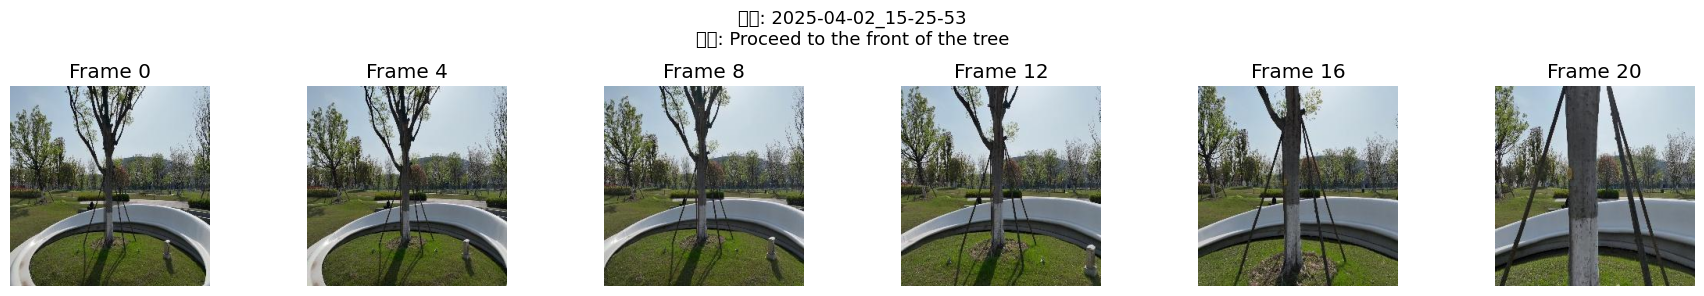

In [4]:
# 展示一条轨迹的关键帧
images = sorted(list(sample_traj.glob('*.jpg')))
n_frames = len(images)

# 均匀采样 6 帧
indices = np.linspace(0, n_frames - 1, 6, dtype=int)
fig, axes = plt.subplots(1, 6, figsize=(18, 3))
fig.suptitle(f"轨迹: {log['id']}\n指令: {log['instruction']}", fontsize=13)

for ax, idx in zip(axes, indices):
    img = Image.open(images[idx])
    ax.imshow(img)
    ax.set_title(f"Frame {idx}")
    ax.axis('off')

plt.tight_layout()
plt.show()

## 1.5 可视化飞行轨迹 (3D)

从 `raw_logs` 中提取 x, y, z 坐标，绘制无人机的 3D 飞行路径。

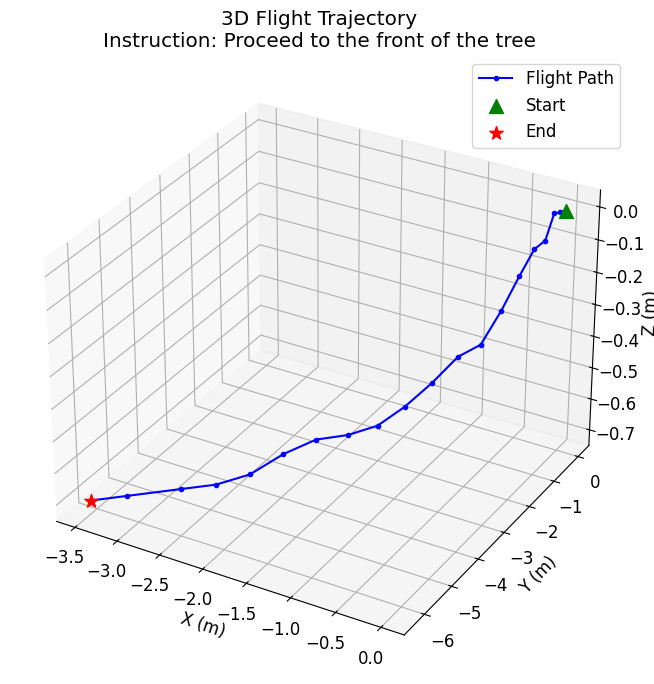

In [5]:
raw = np.array(log['raw_logs'])
x, y, z = raw[:, 0], raw[:, 1], raw[:, 2]

# 将坐标归零到起点
x = x - x[0]
y = y - y[0]
z = z - z[0]

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# 绘制轨迹
ax.plot(x, y, z, 'b-o', markersize=3, linewidth=1.5, label='Flight Path')
ax.scatter(x[0], y[0], z[0], color='green', s=100, marker='^', label='Start')
ax.scatter(x[-1], y[-1], z[-1], color='red', s=100, marker='*', label='End')

ax.set_xlabel('X (m)')
ax.set_ylabel('Y (m)')
ax.set_zlabel('Z (m)')
ax.set_title(f'3D Flight Trajectory\nInstruction: {log["instruction"]}')
ax.legend()
plt.tight_layout()
plt.show()

## 1.6 动作空间分析

UAV-Flow 的原始动作是 6-DoF: `[x, y, z, roll, pitch, yaw]`

在 OpenVLA-UAV 微调中，我们只使用 4 维: **`[x, y, z, yaw]`**（roll 和 pitch 对短距离飞行影响较小）。

下面分析所有轨迹中动作值的分布。

In [6]:
# 收集所有轨迹的 preprocessed_logs
all_actions = []
all_instructions = []

for traj_dir in sorted(DATA_DIR.iterdir()):
    log_path = traj_dir / 'log.json'
    if not log_path.exists():
        continue
    with open(log_path, 'r') as f:
        log_data = json.load(f)
    actions = np.array(log_data['preprocessed_logs'])
    all_actions.append(actions)
    all_instructions.append(log_data.get('instruction', ''))

all_actions = np.concatenate(all_actions, axis=0)
print(f"总动作样本数: {len(all_actions)}")
print(f"动作维度: {all_actions.shape[1]}")
print(f"唯一指令数: {len(set(all_instructions))}")

总动作样本数: 34518
动作维度: 6
唯一指令数: 414


<ipython-input-7-52094eafab6f>:18: UserWarning: Glyph 21069 (\N{CJK UNIFIED IDEOGRAPH-524D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-7-52094eafab6f>:18: UserWarning: Glyph 21518 (\N{CJK UNIFIED IDEOGRAPH-540E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-7-52094eafab6f>:18: UserWarning: Glyph 24038 (\N{CJK UNIFIED IDEOGRAPH-5DE6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-7-52094eafab6f>:18: UserWarning: Glyph 21491 (\N{CJK UNIFIED IDEOGRAPH-53F3}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-7-52094eafab6f>:18: UserWarning: Glyph 19978 (\N{CJK UNIFIED IDEOGRAPH-4E0A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-7-52094eafab6f>:18: UserWarning: Glyph 19979 (\N{CJK UNIFIED IDEOGRAPH-4E0B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-7-52094eafab6f>:18: UserWarning: Glyph 20559 (\N{CJK UNIFIED IDEOGRAPH-504F}) missing from font(s

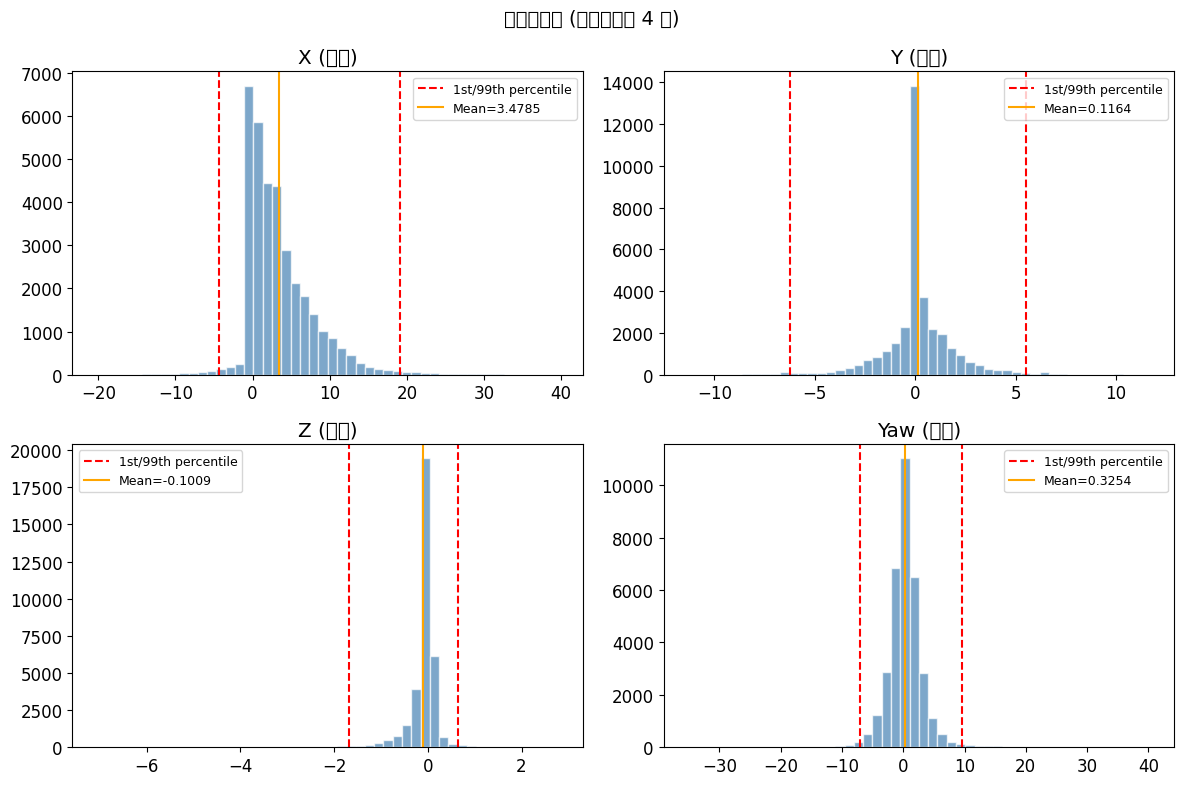

In [7]:
# 动作分布直方图
dim_names = ['X (前后)', 'Y (左右)', 'Z (上下)', 'Roll', 'Pitch', 'Yaw (偏航)']
used_dims = [0, 1, 2, 5]  # 实际使用的 4 维: x, y, z, yaw

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, dim_idx in enumerate(used_dims):
    data = all_actions[:, dim_idx]
    axes[i].hist(data, bins=50, color='steelblue', alpha=0.7, edgecolor='white')
    axes[i].axvline(np.percentile(data, 1), color='red', linestyle='--', label='1st/99th percentile')
    axes[i].axvline(np.percentile(data, 99), color='red', linestyle='--')
    axes[i].axvline(np.mean(data), color='orange', linestyle='-', label=f'Mean={np.mean(data):.4f}')
    axes[i].set_title(f'{dim_names[dim_idx]}')
    axes[i].legend(fontsize=9)

fig.suptitle('动作值分布 (训练使用的 4 维)', fontsize=14)
plt.tight_layout()
plt.show()

In [8]:
# 动作统计摘要
print("动作统计 (用于训练的 4 维: x, y, z, yaw):")
print("-" * 60)
for i, dim_idx in enumerate(used_dims):
    data = all_actions[:, dim_idx]
    print(f"{dim_names[dim_idx]:>12s}: mean={np.mean(data):+.4f}  std={np.std(data):.4f}  "
          f"1%={np.percentile(data, 1):+.4f}  99%={np.percentile(data, 99):+.4f}")

print("\n** 1st/99th 百分位数用于 Action Tokenizer 的离散化边界 **")

动作统计 (用于训练的 4 维: x, y, z, yaw):
------------------------------------------------------------
      X (前后): mean=+3.4785  std=4.4633  1%=-4.3286  99%=+19.1341
      Y (左右): mean=+0.1164  std=1.8066  1%=-6.2186  99%=+5.5184
      Z (上下): mean=-0.1009  std=0.4470  1%=-1.6876  99%=+0.6538
    Yaw (偏航): mean=+0.3254  std=3.0576  1%=-7.0102  99%=+9.6665

** 1st/99th 百分位数用于 Action Tokenizer 的离散化边界 **


## 1.7 语言指令统计

In [9]:
from collections import Counter

# 提取常见关键词
words = []
for inst in all_instructions:
    words.extend(inst.lower().split())

word_freq = Counter(words)
top_words = word_freq.most_common(15)

print("前 15 个高频词:")
for word, count in top_words:
    print(f"  {word:>12s}: {count}")

print(f"\n示例指令:")
for inst in list(set(all_instructions))[:8]:
    print(f"  - {inst}")

前 15 个高频词:
           the: 902
          side: 389
          tree: 305
          from: 265
            to: 242
         right: 211
          left: 159
            on: 138
        toward: 94
          move: 71
          past: 71
       through: 71
   streetlight: 68
        please: 60
            in: 55

示例指令:
  - Suggest progressing through the tree from the right side
  - Turn to face the camera
  - Travel through the tree from the right side
  - Need to navigate past the tree from the left side
  - Circle around the tree in clockwise direction
  - Please go away from the light
  - Proceed toward the tree on the right side
  - Need to advance to the tree from the left side


## 1.8 多轨迹对比可视化

<ipython-input-10-56a42fe73503>:32: UserWarning: Glyph 26679 (\N{CJK UNIFIED IDEOGRAPH-6837}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-10-56a42fe73503>:32: UserWarning: Glyph 26412 (\N{CJK UNIFIED IDEOGRAPH-672C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-10-56a42fe73503>:32: UserWarning: Glyph 23637 (\N{CJK UNIFIED IDEOGRAPH-5C55}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-10-56a42fe73503>:32: UserWarning: Glyph 31034 (\N{CJK UNIFIED IDEOGRAPH-793A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-10-56a42fe73503>:32: UserWarning: Glyph 22270 (\N{CJK UNIFIED IDEOGRAPH-56FE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-10-56a42fe73503>:32: UserWarning: Glyph 20687 (\N{CJK UNIFIED IDEOGRAPH-50CF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-10-56a42fe73503>:32: UserWarning: Glyph 39134 (\N{CJK UNIFIED IDEOGRAPH-98DE}) missing from

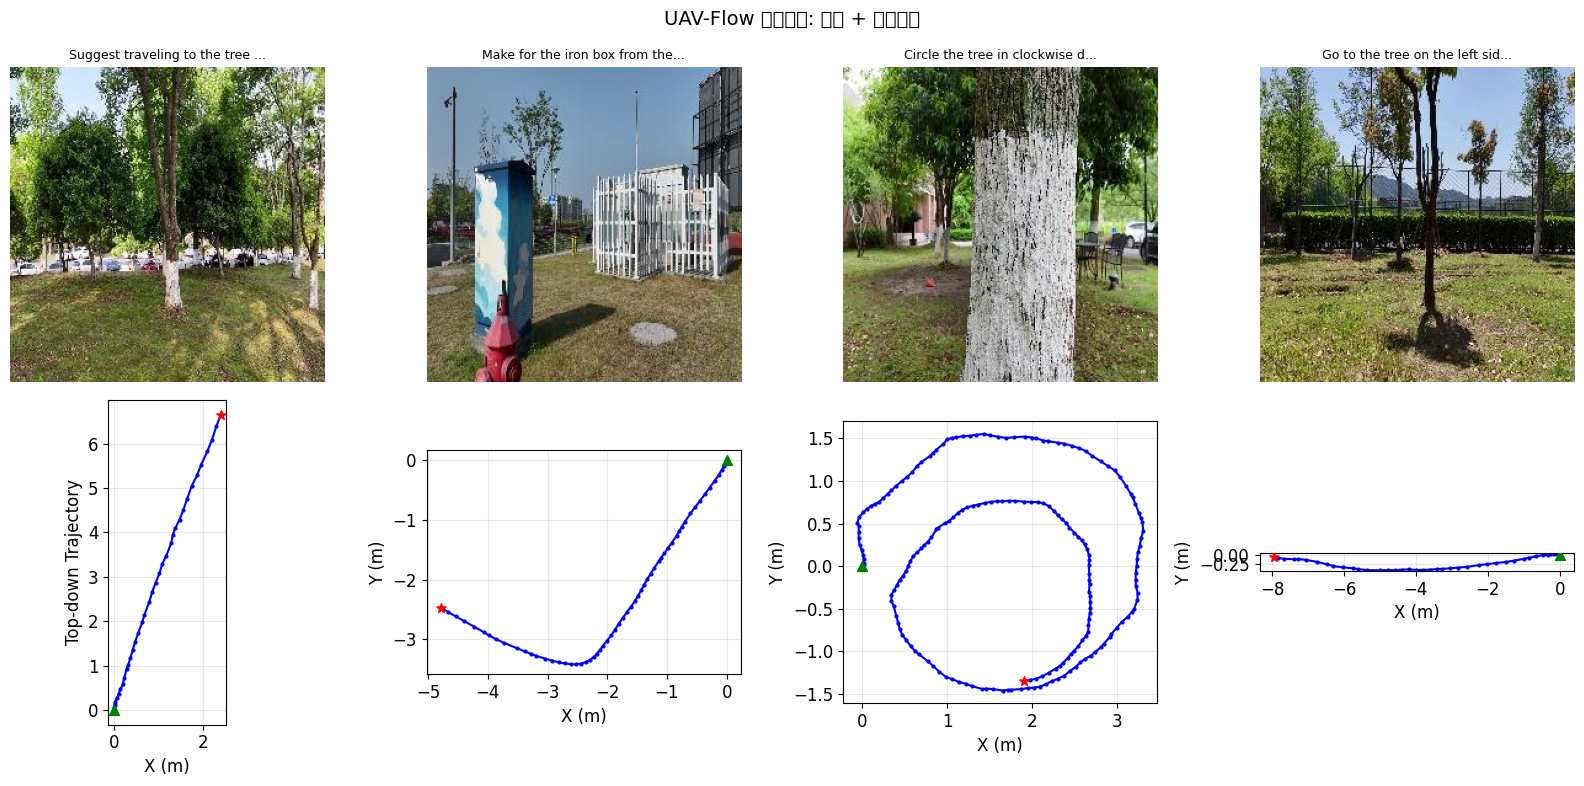

In [10]:
# 随机选择 4 条轨迹，展示图像 + 轨迹
np.random.seed(42)
sample_dirs = np.random.choice(sorted(list(DATA_DIR.iterdir())), size=4, replace=False)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for col, traj_dir in enumerate(sample_dirs):
    with open(traj_dir / 'log.json', 'r') as f:
        log_data = json.load(f)
    
    # 上排: 中间帧图像
    imgs = sorted(list(traj_dir.glob('*.jpg')))
    mid_img = Image.open(imgs[len(imgs)//2])
    axes[0, col].imshow(mid_img)
    axes[0, col].set_title(log_data['instruction'][:30] + '...', fontsize=9)
    axes[0, col].axis('off')
    
    # 下排: 2D 轨迹 (俯视图)
    raw = np.array(log_data['raw_logs'])
    rx, ry = raw[:, 0] - raw[0, 0], raw[:, 1] - raw[0, 1]
    axes[1, col].plot(rx, ry, 'b-o', markersize=2)
    axes[1, col].scatter(rx[0], ry[0], color='green', s=50, zorder=5, marker='^')
    axes[1, col].scatter(rx[-1], ry[-1], color='red', s=50, zorder=5, marker='*')
    axes[1, col].set_xlabel('X (m)')
    axes[1, col].set_ylabel('Y (m)')
    axes[1, col].set_aspect('equal')
    axes[1, col].grid(True, alpha=0.3)

axes[0, 0].set_ylabel('FPV Image', fontsize=12)
axes[1, 0].set_ylabel('Top-down Trajectory', fontsize=12)
plt.suptitle('UAV-Flow 样本展示: 图像 + 飞行轨迹', fontsize=14)
plt.tight_layout()
plt.show()

## 小结

- UAV-Flow 数据集包含真实校园场景的无人机飞行轨迹
- 每条轨迹由 FPV 图像序列 + 语言指令 + 6-DoF 动作组成
- 训练时使用 4 维动作 `[x, y, z, yaw]`，通过 1st/99th 百分位进行归一化
- 动作主要集中在前向运动（x 维度），yaw 控制转向

**下一步:** 在 Notebook 02 中，我们将了解 OpenVLA 模型如何将图像和语言指令转换为动作预测。